# Loading Dataset

In [ ]:
import pandas as pd
import os

In [2]:
def load_dataset(root: str, subset: str) -> pd.DataFrame:
    subset_path = os.path.join(root, subset)

    if not os.path.exists(subset_path):
        raise FileNotFoundError(f"Directory not found: {subset_path}")
    
    dfs = []

    # Finds all relevant dataset files
    files = [file for file in os.listdir(subset_path) if file.endswith(".pcap.csv")] 

    for filename in files:
        file_suffix = f"_{subset}.pcap.csv"
        if filename.endswith(file_suffix):
            clean_name = filename[:-len(file_suffix)]

        if clean_name and clean_name[-1].isdigit():
            attack_label = clean_name[:-1]
        else:
            attack_label = clean_name
        
        #Grouping by dataset description categories (https://www.unb.ca/cic/datasets/iomt-dataset-2024.html)
        if "Benign" in attack_label:
            attack_category = "Benign"
        elif "MQTT" in attack_label:
            attack_category = "MQTT"
        elif "Recon" in attack_label:
            attack_category = "Recon"
        elif "Spoofing" in attack_label or "ARP" in attack_label:
            category = "Spoofing"
        elif "DDoS" in attack_label:
            attack_category = "DDoS"
        elif "DoS" in attack_label:
            attack_category = "DoS"
        else:
            attack_category = "Other"
        
        file_path = os.path.join(subset_path, filename)
        try:
            df = pd.read_csv(file_path)

            df["Category"] = attack_category
            df["Attack"] = attack_label

            dfs.append(df)

        except Exception as e:
            print(f"Error loading {filename}: {e}")
    
    if not dfs:
        print(f"No files found in {subset_path}")
        return pd.DataFrame()
    
    return pd.concat(dfs, ignore_index = True)
   

In [ ]:
dataset = pd.concat([train, test], ignore_index=True) # Combining train and test sets to analyse full dataset

# Dataset Analysis

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
sns.set_theme(
    style = "whitegrid",
    context = "paper",
    palette = "viridis"
)

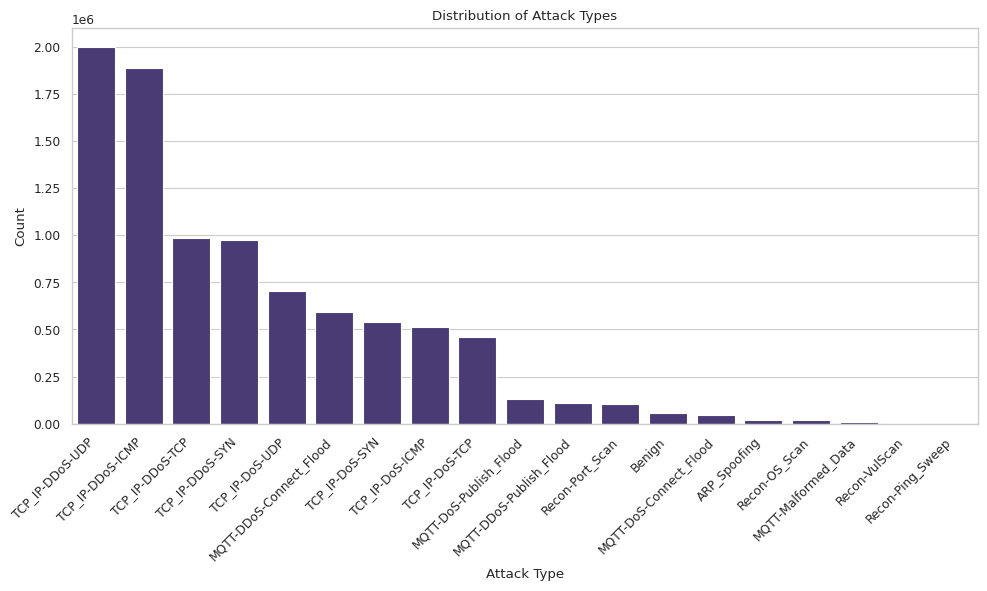

In [6]:
plt.figure(figsize = (10,6))
sns.countplot(
    data = dataset,
    x = "Attack",
    order = dataset["Attack"].value_counts().index
)
plt.title("Distribution of Attack Types")
plt.xlabel("Attack Type")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()

In [ ]:
attack_counts = dataset["Attack"].value_counts()

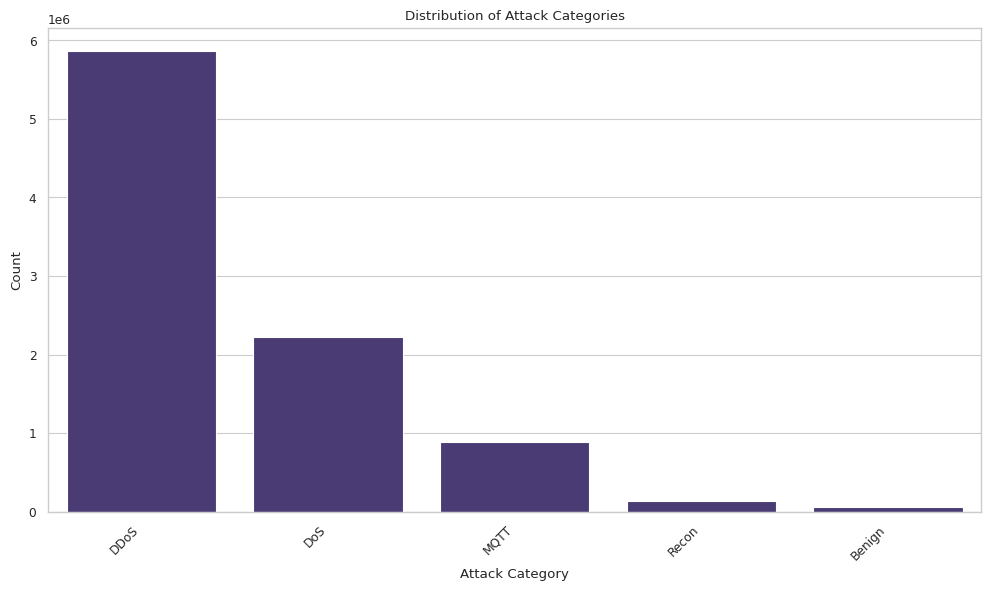

: 

In [ ]:
plt.figure(figsize = (10,6))
sns.countplot(
    data = dataset,
    x = "Category",
    order = dataset["Category"].value_counts().index
)
plt.title("Distribution of Attack Categories")
plt.xlabel("Attack Category")
plt.ylabel("Count")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
